# Support-Aware SQR Optimization Demo

This notebook demonstrates an end-to-end workflow for **support-aware SQR optimization**:
1. Configure cQED context.
2. Choose target SQR and active cavity support.
3. Evaluate baseline (unoptimized) pulse.
4. Run support-aware optimization (Case E default, Case D fallback).
5. Compare waveform and metrics before/after.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import examples.studies.sqr_multitone_study as sms

## Context / System Configuration

Choose one source:
- `manual`
- `preset`
- `json_file`

The resulting `system_params` is the Hamiltonian context used for all simulations.

In [2]:
# ===== Context source =====
context_source = 'preset'  # 'manual' | 'preset' | 'json_file'
context_preset_name = 'chi_nominal'
context_json_path = Path('outputs/context_config.json')

# ===== Manual context =====
manual_context = {
    'n_max': 6,
    'chi_nominal_hz': -2.84e6,
    'chi_easy_hz': -2.84e6,
    'chi_hard_hz': -2.84e6,
    'kerr_hz': 0.0,
    'chi2_hz': 0.0,
    'chi3_hz': 0.0,
    'omega_c_hz': 0.0,
    'omega_q_hz': 0.0,
    'qubit_alpha_hz': 0.0,
    'use_rotating_frame': True,
}

PRESET_CONTEXTS = {
    'chi_nominal': dict(manual_context),
    'stronger_dispersion': {**manual_context, 'chi_nominal_hz': -5.2e6, 'chi_easy_hz': -5.2e6, 'chi_hard_hz': -5.2e6},
    'weaker_dispersion': {**manual_context, 'chi_nominal_hz': -1.0e6, 'chi_easy_hz': -1.0e6, 'chi_hard_hz': -1.0e6},
}

if context_source == 'manual':
    cfg = manual_context
elif context_source == 'preset':
    cfg = PRESET_CONTEXTS[context_preset_name]
elif context_source == 'json_file':
    payload = json.loads(context_json_path.read_text(encoding='utf-8'))
    cfg = {**manual_context, **payload}
else:
    raise ValueError(f'Unsupported context_source: {context_source}')

system_params = sms.SystemParams(**cfg)
print(system_params)

SystemParams(n_max=6, omega_c_hz=0.0, omega_q_hz=0.0, qubit_alpha_hz=0.0, chi_nominal_hz=-2840000.0, chi_easy_hz=-2840000.0, chi_hard_hz=-2840000.0, chi2_hz=0.0, chi3_hz=0.0, kerr_hz=0.0, use_rotating_frame=True)


## Target SQR / Support Configuration

Edit this single cell to set:
- target profile,
- active support set and weights,
- pulse duration/envelope,
- optimization objective weights,
- ansatz mode (Case E default).

In [3]:
seed = 123

# ----- Target selection -----
target_mode = 'manual'  # 'manual' | 'structured' | 'moderate_random' | 'hard_random'
manual_theta = [np.pi/2, 0, 0.0, 0.0, 0.0, 0.0, 0.0]  # length <= n_cav
manual_phi = [0.0, 0, 0.0, 0.0, 0.0, 0.0, 0.0]

# ----- Active support selection -----
support_mode = 'explicit'  # 'contiguous' | 'explicit' | 'from_state'
max_level_active = 1
active_levels = (0, 1,2)
active_weights = ()  # e.g. (0.7, 0.3); empty => uniform or inferred
inference_state_label = 'g x (|0>+|1>)/sqrt2'
state_population_threshold = 1.0e-4
infer_weights_from_state = True

# ----- Pulse/optimizer settings -----
duration_s = 1.0e-6
envelope_kind = 'gaussian'  # 'gaussian' | 'flat_top'
case_primary = sms.MODE_CHIRP      # Case E default
case_fallback = sms.MODE_EXTENDED  # Case D fallback

support_weights = sms.SupportObjectiveWeights(
    w_active_infidelity=1.0,
    w_active_theta=0.20,
    w_active_phase_axis=0.35,
    w_active_pre_z=0.25,
    w_active_post_z=0.25,
    w_active_state_mean=0.60,
    w_active_state_min=0.50,
    w_phase_superposition=0.40,
    w_leak_mean=0.80,
    w_leak_max=0.65,
    w_worst_block=0.90,
    active_block_fidelity_floor=0.98,
    active_state_fidelity_floor=0.97,
)

opt_params = sms.OptimizationParams(
    objective_scope='support_aware',
    support_weights=support_weights,
)

pulse_params = sms.PulseParams(duration_nominal_s=duration_s, envelope_kind=envelope_kind)

study_params = sms.StudyParams(
    seed=seed,
    system=system_params,
    pulse=pulse_params,
    optimization=opt_params,
)

support_params = sms.ActiveSupportParams(
    mode=support_mode,
    max_level_active=max_level_active,
    active_levels=tuple(active_levels),
    active_weights=tuple(active_weights),
    inference_state_label=inference_state_label,
    state_population_threshold=state_population_threshold,
    infer_weights_from_state=infer_weights_from_state,
    inactive_weight=0.02,
    boundary_leakage_boost=1.6,
)

n_levels = int(study_params.system.n_cav)
if target_mode == 'manual':
    theta = np.zeros(n_levels, dtype=float)
    phi = np.zeros(n_levels, dtype=float)
    l = min(len(manual_theta), n_levels)
    theta[:l] = np.asarray(manual_theta[:l], dtype=float)
    phi[:l] = np.asarray(manual_phi[:l], dtype=float)
    profile = sms.TargetProfile(name='manual_target', mode='manual', theta=theta, phi=phi, seed=seed)
else:
    profile = sms.build_target_profile(
        mode=target_mode,
        n_levels=n_levels,
        seed=seed,
        theta_max=float(study_params.theta_max_rad),
    )

print(profile.name)
print('theta:', np.round(profile.theta, 4))
print('phi:', np.round(profile.phi, 4))

manual_target
theta: [1.5708 0.     0.     0.     0.     0.     0.    ]
phi: [0. 0. 0. 0. 0. 0. 0.]


## Build Model and Baseline (Unoptimized) Pulse

In [4]:
model, frame = sms.build_model_and_frame(study_params.system, chi_hz=float(study_params.system.chi_nominal_hz))
reference_states = sms.build_reference_states(model, n_max=study_params.system.n_max, coherent_alpha=study_params.coherent_alpha)
ideal_outputs = sms.apply_unitary_to_states(sms.build_target_unitary(profile), reference_states)

controls = sms.build_controls_from_target(
    profile=profile,
    model=model,
    frame=frame,
    duration_s=float(study_params.pulse.duration_nominal_s),
    theta_cutoff=float(study_params.pulse.theta_cutoff),
)

case_B = sms.build_case(
    case_id='B',
    description='Baseline unoptimized pulse',
    controls=controls,
    model=model,
    frame=frame,
    profile=profile,
    pulse_params=study_params.pulse,
    duration_s=float(study_params.pulse.duration_nominal_s),
    dt_s=float(study_params.pulse.dt_eval_s),
    max_step_s=float(study_params.pulse.max_step_eval_s),
    reference_states=reference_states,
    ideal_state_outputs=ideal_outputs,
)

print(case_B.summary)

{'n_levels': 7, 'mean_process_fidelity': 0.5452040987979653, 'min_process_fidelity': 0.01840415746639921, 'mean_infidelity': 0.4547959012020349, 'mean_population_error': 1.217096367543535e-05, 'phase_rms_rad': 2.343533892130371, 'phase_axis_rms_rad': 2.343533892130371, 'relative_block_phase_rms_rad': 0.8705767627885533, 'theta_rms_rad': 1.722522750779672, 'residual_z_rms_rad': 1.7225122019490255, 'max_abs_phase_axis_error_rad': 3.1322540482959065, 'max_abs_relative_phase_rad': 1.4544310995960483, 'off_block_norm': 0.0, 'population_phase_mismatch_example': {'n': 3, 'population_error': 5.299583759517926e-07, 'process_infidelity': 0.9815958425336008, 'phi_axis_error_rad': 3.0521448326098746, 'relative_block_phase_rad': 1.4544310995960483, 'residual_conditional_z_rad': 2.8694288153170455}, 'neighbor_overlap_proxy_mean': 1.2009329048510239e-05, 'neighbor_overlap_proxy_max': 0.00014411194858212286, 'state_fidelity_mean': 0.9376909863885512, 'state_fidelity_min': 0.5033976389103215}


## Support-Aware Evaluation Helpers

In [5]:
def build_support_context(case):
    support_ref = sms.select_support_reference_state(reference_states, support_params)
    active_levels, active_weights_map, inactive_levels = sms.resolve_active_support(
        profile.n_levels,
        support=support_params,
        reference_state=support_ref,
    )
    support_states = sms.build_active_support_ensemble(
        model=model,
        active_levels=active_levels,
        support=support_params,
        active_weights=active_weights_map,
    )
    support_ideal = sms.apply_unitary_to_states(sms.build_target_unitary(profile), support_states)
    support_metrics = sms.support_metrics_for_case(
        case=case,
        profile=profile,
        model=model,
        frame=frame,
        pulse=study_params.pulse,
        duration_s=float(study_params.pulse.duration_nominal_s),
        support=support_params,
        support_states=support_states,
        support_ideal_outputs=support_ideal,
        support_reference_state=support_ref,
    )
    return active_levels, active_weights_map, inactive_levels, support_metrics


def metric_snapshot(case):
    active_levels, active_weights_map, inactive_levels, support_metrics = build_support_context(case)
    return {
        'active_levels': active_levels,
        'active_weights': active_weights_map,
        'inactive_levels': inactive_levels,
        'support': {
            'active_weighted_mean_process_fidelity': support_metrics['active_weighted_mean_process_fidelity'],
            'active_min_process_fidelity': support_metrics['active_min_process_fidelity'],
            'active_theta_rms_rad': support_metrics['active_theta_rms_rad'],
            'active_phase_axis_rms_rad': support_metrics['active_phase_axis_rms_rad'],
            'active_residual_pre_z_rms_rad': support_metrics['active_residual_pre_z_rms_rad'],
            'active_residual_post_z_rms_rad': support_metrics['active_residual_post_z_rms_rad'],
            'support_state_fidelity_mean': support_metrics['support_state_fidelity_mean'],
            'support_state_fidelity_min': support_metrics['support_state_fidelity_min'],
            'support_phase_superposition_rms_rad': support_metrics['support_phase_superposition_rms_rad'],
            'support_state_leakage_mean': support_metrics['support_state_leakage_mean'],
            'support_state_leakage_max': support_metrics['support_state_leakage_max'],
            'support_weighted_leakage_mean': support_metrics['support_weighted_leakage_mean'],
            'support_weighted_leakage_max': support_metrics['support_weighted_leakage_max'],
            'support_worst_leakage_channel': support_metrics['support_worst_leakage_channel'],
        },
        'global': {
            'mean_process_fidelity': case.summary['mean_process_fidelity'],
            'min_process_fidelity': case.summary['min_process_fidelity'],
            'phase_sensitive_rms_proxy': case.summary.get('phase_rms_rad', np.nan),
            'state_fidelity_mean': case.summary.get('state_fidelity_mean', np.nan),
            'state_fidelity_min': case.summary.get('state_fidelity_min', np.nan),
        },
    }

baseline_snapshot = metric_snapshot(case_B)
print(json.dumps(baseline_snapshot, indent=2, default=str))

{
  "active_levels": [
    0,
    1,
    2
  ],
  "active_weights": {
    "0": 0.49999999999949996,
    "1": 0.49999999999949996,
    "2": 9.99999999999e-13
  },
  "inactive_levels": [
    3,
    4,
    5,
    6
  ],
  "support": {
    "active_weighted_mean_process_fidelity": 0.9159205864757863,
    "active_min_process_fidelity": 0.3480060324964706,
    "active_theta_rms_rad": 0.5975514916142469,
    "active_phase_axis_rms_rad": 2.207778791406872,
    "active_residual_pre_z_rms_rad": 0.29873059130005486,
    "active_residual_post_z_rms_rad": 0.298730591300054,
    "support_state_fidelity_mean": 0.9456775000232607,
    "support_state_fidelity_min": 0.6008557246426418,
    "support_phase_superposition_rms_rad": 0.03952266995785383,
    "support_state_leakage_mean": 4.1045396748096156e-09,
    "support_state_leakage_max": 3.892972311181353e-08,
    "support_weighted_leakage_mean": 0.0,
    "support_weighted_leakage_max": 0.0,
    "support_worst_leakage_channel": {
      "from_manifold": 2

## Run Optimization (Support-Aware)

- Primary: Case E (`MODE_CHIRP`)
- Fallback/ablation: Case D (`MODE_EXTENDED`)

In [6]:
from dataclasses import replace
case_D = sms.optimize_case(
    mode=case_fallback,
    base_controls=controls,
    model=model,
    frame=frame,
    profile=profile,
    pulse_params=study_params.pulse,
    opt_params=replace(study_params.optimization, objective_scope='support_aware'),
    duration_s=float(study_params.pulse.duration_nominal_s),
    reference_states=reference_states,
    ideal_state_outputs=ideal_outputs,
    support_config=support_params,
)

case_E = sms.optimize_case(
    mode=case_primary,
    base_controls=controls,
    model=model,
    frame=frame,
    profile=profile,
    pulse_params=study_params.pulse,
    opt_params=replace(study_params.optimization, objective_scope='support_aware'),
    duration_s=float(study_params.pulse.duration_nominal_s),
    reference_states=reference_states,
    ideal_state_outputs=ideal_outputs,
    support_config=support_params,
)

snap_D = metric_snapshot(case_D)
snap_E = metric_snapshot(case_E)

## Before vs After Metrics (Support + Global)

In [7]:
def compare_rows(label, snap):
    s = snap['support']
    g = snap['global']
    return {
        'label': label,
        'active_mean_fid': s['active_weighted_mean_process_fidelity'],
        'active_min_fid': s['active_min_process_fidelity'],
        'active_phase_rms': s['active_phase_axis_rms_rad'],
        'active_theta_rms': s['active_theta_rms_rad'],
        'active_pre_z_rms': s['active_residual_pre_z_rms_rad'],
        'active_post_z_rms': s['active_residual_post_z_rms_rad'],
        'support_state_mean': s['support_state_fidelity_mean'],
        'support_state_min': s['support_state_fidelity_min'],
        'phase_super_rms': s['support_phase_superposition_rms_rad'],
        'support_leak_mean': s['support_state_leakage_mean'],
        'support_leak_max': s['support_state_leakage_max'],
        'global_mean_fid': g['mean_process_fidelity'],
        'global_min_fid': g['min_process_fidelity'],
        'global_phase_rms': g['phase_sensitive_rms_proxy'],
    }

rows = [
    compare_rows('Baseline (B)', baseline_snapshot),
    compare_rows('Fallback (D)', snap_D),
    compare_rows('Support-aware primary (E)', snap_E),
]

for row in rows:
    print(row)

{'label': 'Baseline (B)', 'active_mean_fid': 0.9159205864757863, 'active_min_fid': 0.3480060324964706, 'active_phase_rms': 2.207778791406872, 'active_theta_rms': 0.5975514916142469, 'active_pre_z_rms': 0.29873059130005486, 'active_post_z_rms': 0.298730591300054, 'support_state_mean': 0.9456775000232607, 'support_state_min': 0.6008557246426418, 'phase_super_rms': 0.03952266995785383, 'support_leak_mean': 4.1045396748096156e-09, 'support_leak_max': 3.892972311181353e-08, 'global_mean_fid': 0.5452040987979653, 'global_min_fid': 0.01840415746639921, 'global_phase_rms': 2.343533892130371}
{'label': 'Fallback (D)', 'active_mean_fid': 0.899767655303754, 'active_min_fid': 0.3503479691324932, 'active_phase_rms': 0.04558869633217404, 'active_theta_rms': 0.5978666462912423, 'active_pre_z_rms': 0.31622045797373943, 'active_post_z_rms': 0.31591628795291643, 'support_state_mean': 0.9422058590319746, 'support_state_min': 0.6176955063834008, 'phase_super_rms': 0.13224065076834557, 'support_leak_mean':

## Time-Domain Waveform Comparison (Unoptimized vs Optimized)

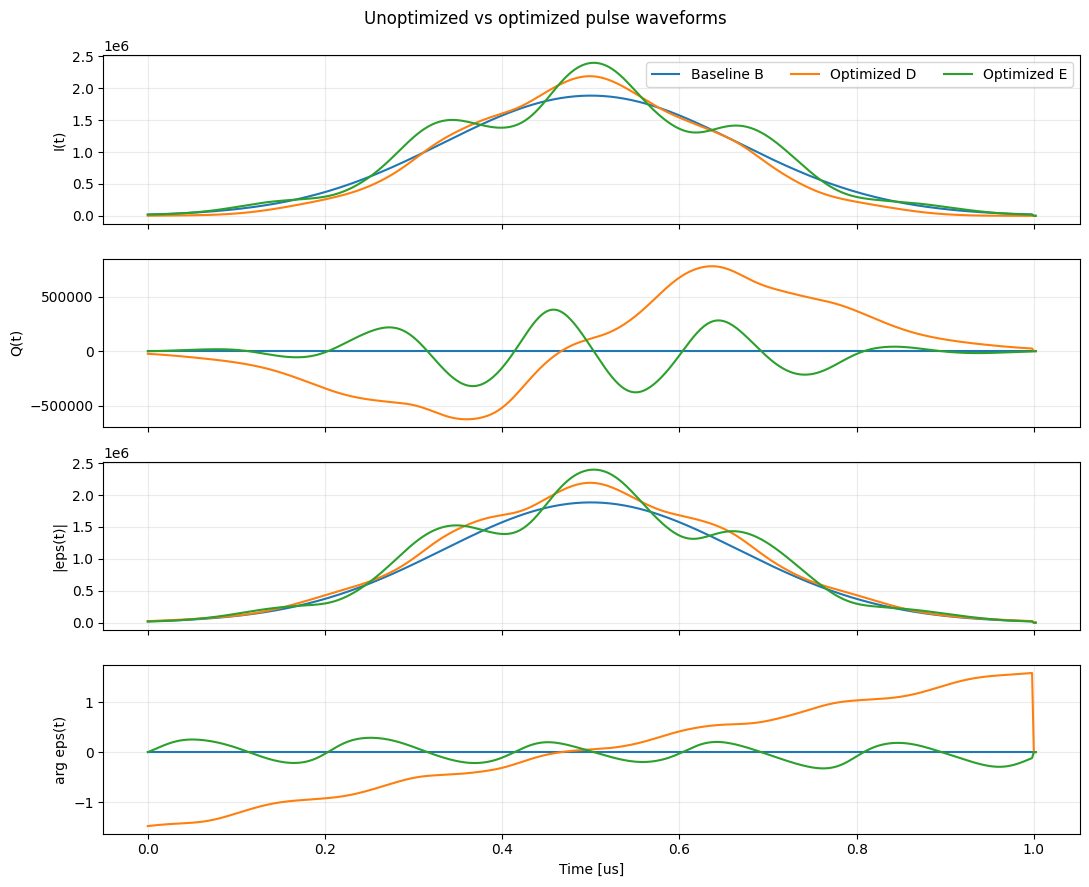

In [8]:
def waveform_arrays(case):
    sig = np.asarray(case.compiled.channels['qubit'].distorted, dtype=np.complex128)
    t = np.asarray(case.compiled.tlist, dtype=float) * 1.0e6
    amp = np.abs(sig)
    phase = np.unwrap(np.angle(sig))
    return t, sig.real, sig.imag, amp, phase

series = {
    'Baseline B': waveform_arrays(case_B),
    'Optimized D': waveform_arrays(case_D),
    'Optimized E': waveform_arrays(case_E),
}

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for label, (t, i, q, amp, ph) in series.items():
    axes[0].plot(t, i, label=label)
    axes[1].plot(t, q, label=label)
    axes[2].plot(t, amp, label=label)
    axes[3].plot(t, ph, label=label)
axes[0].set_ylabel('I(t)')
axes[1].set_ylabel('Q(t)')
axes[2].set_ylabel('|eps(t)|')
axes[3].set_ylabel('arg eps(t)')
axes[3].set_xlabel('Time [us]')
for ax in axes:
    ax.grid(alpha=0.25)
axes[0].legend(ncol=3)
fig.suptitle('Unoptimized vs optimized pulse waveforms')
fig.tight_layout()
plt.show()

## Final Active-Block Comparison

In [9]:
def active_block_table(case, snap):
    support_metrics = snap['support']
    active = set(snap['active_levels'])
    rows = []
    for row in case.block_rows:
        n = int(row['n'])
        if n not in active:
            continue
        rows.append({
            'n': n,
            'process_fidelity': float(row['process_fidelity']),
            'theta_err': float(row['theta_simulated_rad'] - row['theta_target_rad']),
            'phase_axis_err': float(row['phi_axis_error_rad']),
            'residual_conditional_z': float(row['residual_conditional_z_rad']),
        })
    return rows, support_metrics.get('support_worst_leakage_channel', None)
for label, case, snap in [
    ('Baseline B', case_B, baseline_snapshot),
    ('Optimized D', case_D, snap_D),
    ('Optimized E', case_E, snap_E),
]:
    rows, worst = active_block_table(case, snap)
    print('\n' + label)
    for row in rows:
        print(row)
    print('worst support leakage channel:', worst)



Baseline B
{'n': 0, 'process_fidelity': 0.999999999310988, 'theta_err': -5.2498089669006376e-05, 'phase_axis_err': 0.0, 'residual_conditional_z': 0.0}
{'n': 1, 'process_fidelity': 0.8318411736417203, 'theta_err': 0.8450654220227102, 'phase_axis_err': 3.1222707095257896, 'residual_conditional_z': 0.8449221014607422}
{'n': 2, 'process_fidelity': 0.3480060324964706, 'theta_err': 1.8796722364941265, 'phase_axis_err': 3.085766458508198, 'residual_conditional_z': 1.8796705631048805}
worst support leakage channel: {'from_manifold': 2, 'to_manifold': 3, 'value': 0.0}

Optimized D
{'n': 0, 'process_fidelity': 0.967053421630019, 'theta_err': -0.06039975915403328, 'phase_axis_err': 0.05435478492669077, 'residual_conditional_z': -0.2955141615287925}
{'n': 1, 'process_fidelity': 0.8324818889785878, 'theta_err': 0.8433510079337636, 'phase_axis_err': 0.03467298403815855, 'residual_conditional_z': 0.8433176519792395}
{'n': 2, 'process_fidelity': 0.3503479691324932, 'theta_err': 1.8747595228853668, 'p

## Recommendation Summary

- Use **Case E** as default for support-aware optimization.
- Use **Case D** when you need lower complexity/runtime.
- Pass active support via `ActiveSupportParams`:
  - explicit: `mode='explicit', active_levels=(...)`
  - contiguous: `mode='contiguous', max_level_active=m`
  - inferred: `mode='from_state', inference_state_label='...', state_population_threshold=...`
- Pass support weights via `active_weights`, or infer from reference state (`infer_weights_from_state=True`).